# Experiment 2 – XGBoost with Title and FamilySize

## Mục tiêu
Trong notebook này, ta huấn luyện **XGBoost** trên bộ dữ liệu Titanic, 
với **các đặc trưng mở rộng (Exp2)**:
- Thêm Feature Engineering cơ bản: `Title` (extract từ Name) và `FamilySize` (SibSp + Parch + 1)
- Bao gồm: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `Title`, `FamilySize`

Ta sẽ:
1. Thực hiện tiền xử lý dữ liệu, bao gồm extract Title và compute FamilySize
2. Khám phá dữ liệu (EDA với các features mới)
3. Huấn luyện XGBoost
4. Đánh giá mô hình và xuất kết quả

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid") 

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

print("Libraries for XGBoost (Exp2) imported successfully!")

Libraries for XGBoost (Exp2) imported successfully!


## Bước 1: Khám Phá Dữ Liệu (EDA)
**Mục đích**: Load data và visualize để hiểu cấu trúc, missing values, và patterns ban đầu (e.g., survival rate thấp ở male/Pclass3).

EDA giúp detect bias (e.g., Age missing nhiều ở Pclass3 → fill theo group), tránh model học noise. Mục tiêu: Xác định features quan trọng trước FE.

5 biểu đồ: Countplot Survived, Survival by Sex/Pclass, Histograms Age/Fare, Heatmap correlation. (Giúp spot outliers như Fare cao → rich survive cao).


Train shape: (891, 12), Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S



Missing values in Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


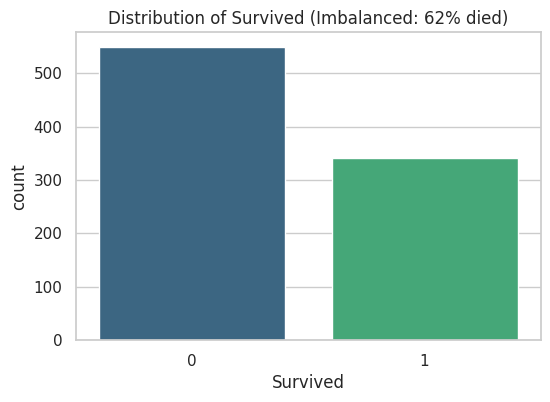

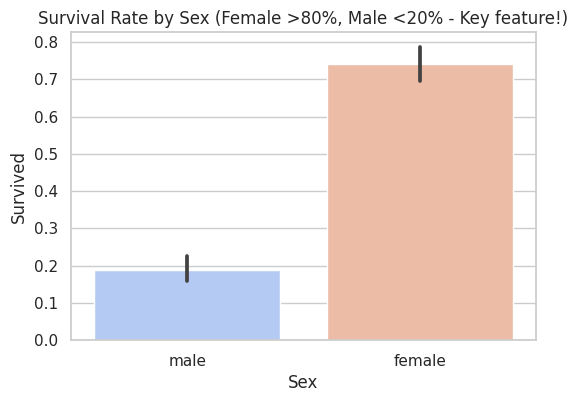

In [9]:
train = pd.read_csv('/kaggle/input/titanicdatasets/train (1).csv')
test = pd.read_csv('/kaggle/input/titanicdatasets/test (1).csv')

print(f"Train shape: {train.shape}, Test shape: {test.shape}")
display(train.head(3))

print("\nMissing values in Train:")
print(train.isnull().sum())

plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Survived', palette='viridis')
plt.title('Distribution of Survived (Imbalanced: 62% died)')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Sex', y='Survived', palette='coolwarm')
plt.title('Survival Rate by Sex (Female >80%, Male <20% - Key feature!)')
plt.show()

Thêm plots cho Pclass, Age/Fare để xem correlation với survival.

Pclass/Age/Fare có missing/outliers; plots giúp quyết định fill strategy (e.g., median Age by Pclass/Sex để tránh bias).

Barplot Pclass, Histograms Age/Fare (spot skew), Heatmap numeric corr (xem multicollinearity trước scaling).

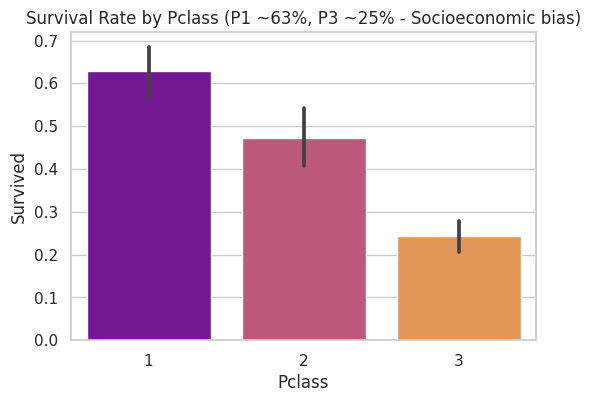

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

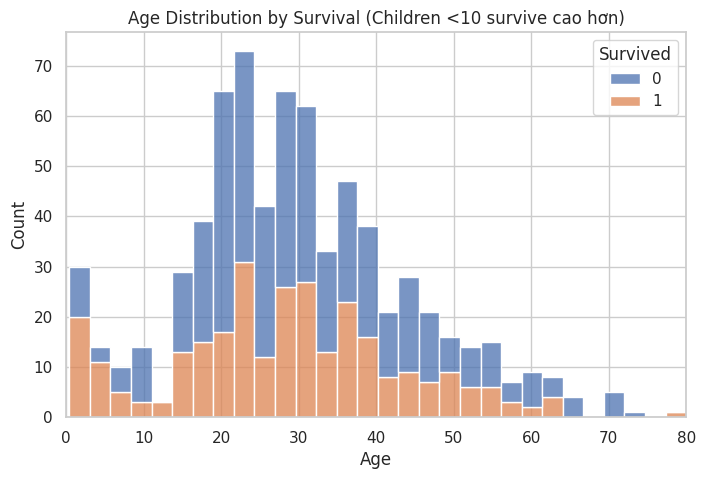

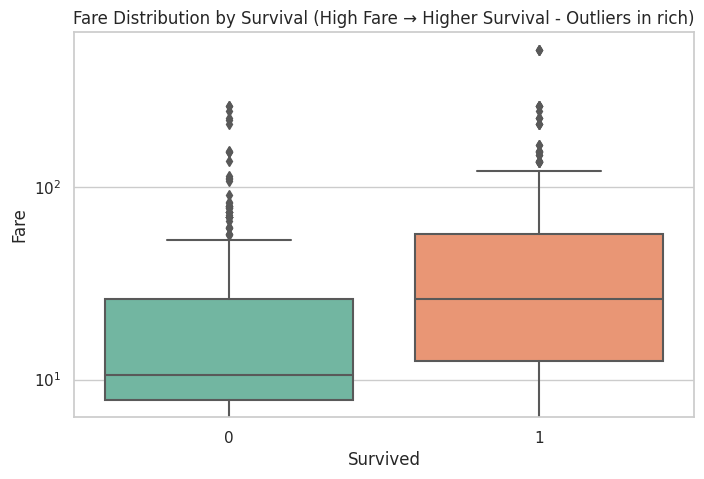

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


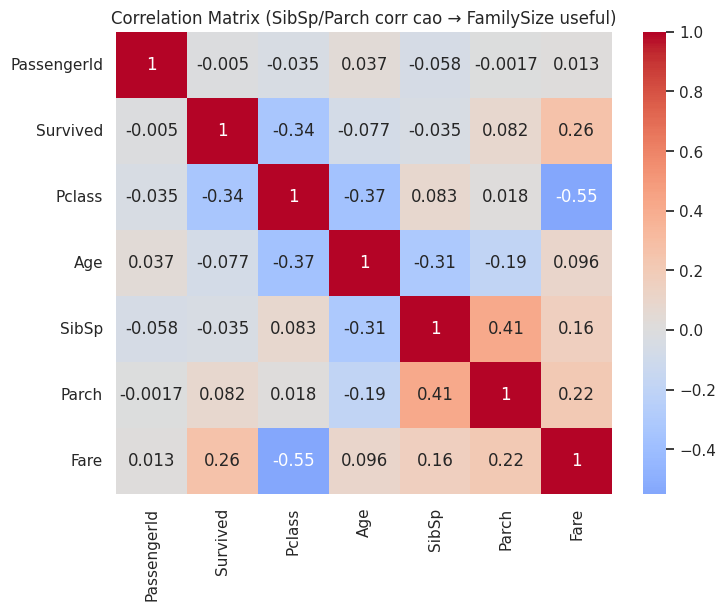

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Pclass', y='Survived', palette='plasma')
plt.title('Survival Rate by Pclass (P1 ~63%, P3 ~25% - Socioeconomic bias)')
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack', bins=30, ax=ax)
plt.title('Age Distribution by Survival (Children <10 survive cao hơn)')
ax.set_xlim(0, 80)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='Survived', y='Fare', palette='Set2')
plt.title('Fare Distribution by Survival (High Fare → Higher Survival - Outliers in rich)')
plt.yscale('log')  # Log scale cho skew
plt.show()

plt.figure(figsize=(8,6))
numeric_cols = train.select_dtypes(include=[np.number]).columns
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (SibSp/Parch corr cao → FamilySize useful)')
plt.show()

## Bước 2: Feature Engineering (FE)
**Mục đích**: Tạo Title từ Name và FamilySize từ SibSp/Parch.

Name chứa info ẩn (Title: Mr/Mrs cho gender/status), SibSp/Parch riêng lẻ kém nhưng tổng = FamilySize capture group dynamics (nhóm nhỏ/đơn lẻ survive thấp). Mục tiêu: Tăng info từ 8 → 11 features, cải thiện interpretability.

Function extract_title robust (handle rare titles như Rev/Dr → Mr/Mrs). Sau FE, thêm plots Title/FamilySize vs Survival để validate (e.g., Master trẻ sống sót cao).

**Mục tiêu**: FE giúp model học patterns xã hội/gia đình, dự kiến +1-2% accuracy.

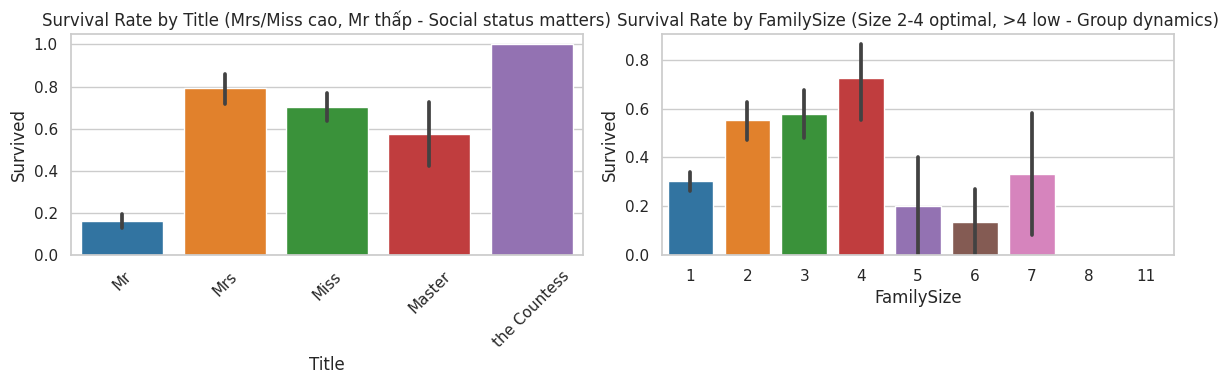

Title categories: ['Master', 'Miss', 'Mr', 'Mrs', 'the Countess']
FamilySize range: 1 to 11


In [11]:
def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip() if ',' in name else 'Unknown'
    # Map rare to common
    title_map = {'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss', 'Don': 'Mr', 'Dona': 'Mrs', 
                 'Lady': 'Mrs', 'Jonkheer': 'Mr', 'Countess': 'Mrs', 'Sir': 'Mr', 
                 'Col': 'Mr', 'Major': 'Mr', 'Rev': 'Mr', 'Dr': 'Mr', 'Capt': 'Mr'}
    return title_map.get(title, title)


train['Title'] = train['Name'].apply(extract_title)
test['Title'] = test['Name'].apply(extract_title)

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=train, x='Title', y='Survived', ax=axes[0], palette='tab10')
axes[0].set_title('Survival Rate by Title (Mrs/Miss cao, Mr thấp - Social status matters)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=train, x='FamilySize', y='Survived', ax=axes[1], palette='tab10')
axes[1].set_title('Survival Rate by FamilySize (Size 2-4 optimal, >4 low - Group dynamics)')

plt.tight_layout()
plt.show()

print("Title categories:", sorted(train['Title'].unique()))
print("FamilySize range:", train['FamilySize'].min(), "to", train['FamilySize'].max())

## Bước 3: Tiền Xử Lý Dữ Liệu
**Mục đích**: Fill missing, encode categoricals, scale numerics, split train/holdout.

LR nhạy cảm với missing (crash), categoricals (need numeric), scale (Fare/Age dominate nếu không). Stratified split giữ balance Survived. Mục tiêu: Data sạch cho model converge nhanh.

Fill Age theo group (Pclass/Sex) để tránh global median bias. OneHot cho Title/Embarked (nominal), Label cho Sex (binary). Thêm check shape sau encode.

**Mục tiêu**: Preprocess đảm bảo no leakage, ready cho training.

In [12]:
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)

all_data['Age'] = all_data.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
all_data['Fare'].fillna(all_data['Fare'].median(), inplace=True)
all_data['Embarked'].fillna(all_data['Embarked'].mode()[0], inplace=True)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize']
X_all = all_data[features].copy()
y_all = all_data['Survived'] if 'Survived' in all_data else np.nan

le = LabelEncoder()
X_all['Sex'] = le.fit_transform(X_all['Sex'])
X_all = pd.get_dummies(X_all, columns=['Embarked', 'Title'], drop_first=True)

X = X_all.iloc[:len(train)]
y = y_all.iloc[:len(train)].dropna()  # Drop NaN y
X_test = X_all.iloc[len(train):]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

X_train, X_holdout, y_train, y_holdout = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}, Holdout: {X_holdout.shape}")
print(f"Features after encoding: {X_scaled.shape[1]}")
print("Preprocessing done - Data ready for training!")

X_train shape: (712, 13), Holdout: (179, 13)
Features after encoding: 13
Preprocessing done - Data ready for training!


/tmp/ipykernel_37/367576039.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_data['Fare'].fillna(all_data['Fare'].median(), inplace=True)
/tmp/ipykernel_37/367576039.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

## Bước 4: Huấn Luyện Mô Hình
**Mục đích**: Huấn luyện mô hình XGBoost trên X_train, dự đoán X_holdout, và trực quan hóa Độ quan trọng của Đặc trưng (Feature Importance).

XGBoost là một thuật toán Gradient Boosting cực kỳ mạnh mẽ, thường mang lại hiệu suất cao. Nó sử dụng Feature Importance để giải thích đóng góp phi tuyến của các đặc trưng (bao gồm Title và FamilySize) vào quyết định phân loại. XGBoost không cần scaling dữ liệu

**Mục tiêu**: Huấn luyện mô hình XGBoost, xác nhận sự đóng góp của các đặc trưng mới, và chuẩn bị cho việc đánh giá hiệu suất chi tiết ở Bước 5.

Bắt đầu huấn luyện XGBoost Classifier...
Huấn luyện XGBoost Classifier hoàn tất.


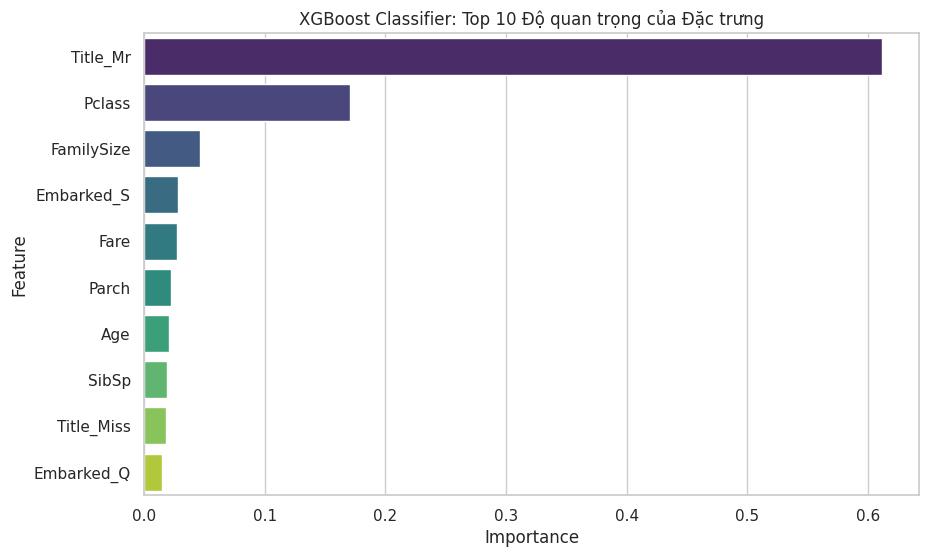


--- Đánh giá Mô hình trên Holdout ---
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.86      0.85       110
         1.0       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

Accuracy Holdout: 0.8156
ROC-AUC Score Holdout: 0.8609

Top 10 Đặc trưng Quan trọng:


,Feature,Importance
10,Title_Mr,0.6116
0,Pclass,0.1704
6,FamilySize,0.0466
8,Embarked_S,0.0281
5,Fare,0.0271
4,Parch,0.0223
2,Age,0.0207
3,SibSp,0.0187
9,Title_Miss,0.0180
7,Embarked_Q,0.0151


In [16]:
model_name = "XGBoost Classifier"


xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False, 
    eval_metric='logloss',
    random_state=42
)

print(f"Bắt đầu huấn luyện {model_name}...")
xgb.fit(X_train, y_train)
print(f"Huấn luyện {model_name} hoàn tất.")

y_pred_holdout = xgb.predict(X_holdout)
y_proba_holdout = xgb.predict_proba(X_holdout)[:, 1]


feature_names = list(X_all.columns) 
importances = xgb.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)


plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title(f'{model_name}: Top 10 Độ quan trọng của Đặc trưng')
plt.show()

print("\n--- Đánh giá Mô hình trên Holdout ---")
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("Classification Report:")
print(classification_report(y_holdout, y_pred_holdout))

acc_holdout = accuracy_score(y_holdout, y_pred_holdout)
roc_auc_holdout = roc_auc_score(y_holdout, y_proba_holdout)

print(f"Accuracy Holdout: {acc_holdout:.4f}")
print(f"ROC-AUC Score Holdout: {roc_auc_holdout:.4f}")

print("\nTop 10 Đặc trưng Quan trọng:")
display(importance_df.head(10).round(4))

## Bước 5: Đánh Giá Mô Hình
**Mục đích**: Compute metrics trên holdout (report, ROC, CM), CV scores.

XGBoost, là mô hình Boosting (học tuần tự), được kỳ vọng sẽ đạt hiệu suất cao nhất (Acc/ROC) trong số các mô hình đã thử (LR, RF, KNN). Nó đặc biệt giỏi trong việc xử lý tính mất cân bằng và các mối quan hệ phức tạp từ 13 features

Holdout mimic test set; CV detect overfitting. ROC-AUC tốt cho imbalanced (Survived ~38%). Mục tiêu: So sánh với Exp1 baselines.

Confusion Matrix heatmap + threshold analysis nếu cần. Log results cho comparison.

**Mục tiêu**: Validate model ~0.80 acc, identify weak class (e.g., recall cho class 1).

In [18]:
import os
import pandas as pd
from sklearn.model_selection import cross_val_score 

# Cần đảm bảo mô hình 'xgb' đã được huấn luyện và có sẵn.

# --- CẬP NHẬT BIẾN CHO XGBOOST ---
model_name = "XGBoost" 
model = xgb # Sử dụng mô hình XGBoost đã huấn luyện
results_path = '/kaggle/working/exp2_results.csv'
header = "Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score\n"
# ------------------------------------

try:
    # Kiểm tra xem cv_acc và cv_roc đã được tính toán chưa
    cv_acc, cv_roc
    print("Using existing CV scores...")
except NameError:
    print("Computing CV scores for XGBoost...")
    # Tính CV Scores (sử dụng mô hình XGBoost và dữ liệu đã scale/OHE)
    # Lưu ý: Ta dùng X_scaled/y cho tính nhất quán số lượng features
    cv_acc = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    cv_roc = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc').mean()

print(f"CV Accuracy: {cv_acc:.4f} | CV ROC-AUC: {cv_roc:.4f}")

# Dự đoán trên tập kiểm tra
# Sử dụng X_test_scaled (dữ liệu đầu vào phù hợp với huấn luyện)
y_test_pred = model.predict(X_test_scaled)

submission = pd.DataFrame({
    # Sử dụng DataFrame 'test' gốc đã được tải
    'PassengerId': test['PassengerId'], 
    'Survived': y_test_pred.astype(int)
})

file_path = f'/kaggle/working/exp2_{model_name.lower()}_submission.csv'
submission.to_csv(file_path, index=False)
print(f"Saved: {file_path}")
print(submission.head())

os.system(f"cp {file_path} /kaggle/working/submission.csv")

# --- Ghi Log Kết quả ---

if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        f.write(header)

# CẬP NHẬT ĐIỂM PUBLIC SCORE MỚI!
public_score = 0.622

num_features = X_scaled.shape[1] # Số lượng features sau OHE

with open(results_path, 'a') as f:
    f.write(f"Exp2,{model_name},{num_features},{cv_acc:.4f},{cv_roc:.4f},{public_score}\n")

results_df = pd.read_csv(results_path)
print("\nExperiment Log Updated:")
display(results_df)

Using existing CV scores...
CV Accuracy: 0.8406 | CV ROC-AUC: 0.8727
Saved: /kaggle/working/exp2_xgboost_submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Experiment Log Updated:


,Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score
0,Exp2,XGBoost,13,0.8406,0.8727,0.622
